In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report)
import tensorflow as tf
from tensorflow.keras.applications import VGG16, InceptionV3, ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import warnings

In [3]:
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Create output directories
os.makedirs('outputs_part2', exist_ok=True)
os.makedirs('outputs_part2/plots', exist_ok=True)
os.makedirs('outputs_part2/models', exist_ok=True)
os.makedirs('outputs_part2/results', exist_ok=True)
os.makedirs('outputs_part2/training_history', exist_ok=True)

print("=" * 80)
print("PW 2 - Part 2: Fine-Tuning Pretrained CNNs")
print("=" * 80)


PW 2 - Part 2: Fine-Tuning Pretrained CNNs


In [ ]:
print("\n[1] Loading and Preprocessing Data...")

# Dataset paths
DATASET_PATH = 'intel-image-classification' 
TRAIN_DIR = os.path.join(DATASET_PATH, 'seg_train', 'seg_train')

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE =  32# For training
EPOCHS = 20
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
NUM_CLASSES = len(CLASSES)

def load_images_from_directory(directory, img_size=IMG_SIZE, max_images=None):
    """Load images from directory structure"""
    images = []
    labels = []
    
    for class_name in CLASSES:
        class_dir = os.path.join(directory, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: Directory not found: {class_dir}")
            continue
            
        image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        if max_images:
            image_files = image_files[:max_images // NUM_CLASSES]
        
        print(f"  Loading {len(image_files)} images from {class_name}...")
        
        for img_file in image_files:
            img_path = os.path.join(class_dir, img_file)
            try:
                img = load_img(img_path, target_size=img_size)
                img_array = img_to_array(img)
                img_array = img_array / 255.0
                
                images.append(img_array)
                labels.append(class_name)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    return np.array(images), np.array(labels)



[1] Loading and Preprocessing Data...


In [5]:
# Load data
X_all, y_all = load_images_from_directory(TRAIN_DIR, max_images=1000)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_all)
y_categorical = to_categorical(y_encoded, NUM_CLASSES)

# Split data (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_categorical, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, 
    stratify=np.argmax(y_temp, axis=1)
)

print(f"\nData split complete:")
print(f"  Train: {len(X_train)} images")
print(f"  Val:   {len(X_val)} images")
print(f"  Test:  {len(X_test)} images")


  Loading 166 images from buildings...
  Loading 166 images from forest...
  Loading 166 images from glacier...
  Loading 166 images from mountain...
  Loading 166 images from sea...
  Loading 166 images from street...

Data split complete:
  Train: 697 images
  Val:   149 images
  Test:  150 images


Starting model evaluation...
ℹ class_names not defined, using auto-generated names
ℹ Class names not provided, using: ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
MODEL EVALUATION AND VISUALIZATION
Found 14 model(s) in outputs_part2/models


  ✓ Loaded: InceptionV3_freeze0


  ✓ Loaded: InceptionV3_freeze100


  ✓ Loaded: InceptionV3_freeze25


  ✓ Loaded: InceptionV3_freeze50


...

  ✓ Loaded: ResNet50_freeze25


  ✓ Loaded: ResNet50_freeze50


  ✓ Loaded: ResNet50_freeze75
  ✓ Loaded: VGG16_freeze0


  ✓ Loaded: VGG16_freeze100
  ✓ Loaded: VGG16_freeze25


  ✓ Loaded: VGG16_freeze50
  ✓ Loaded: VGG16_freeze75

Evaluating 14 model(s)

Evaluating: InceptionV3_freeze0
  Accuracy:  0.8200
  Precision: 0.8275
  Recall:    0.8200
  F1-Score:  0.8193
  ROC AUC (macro): 0.9835


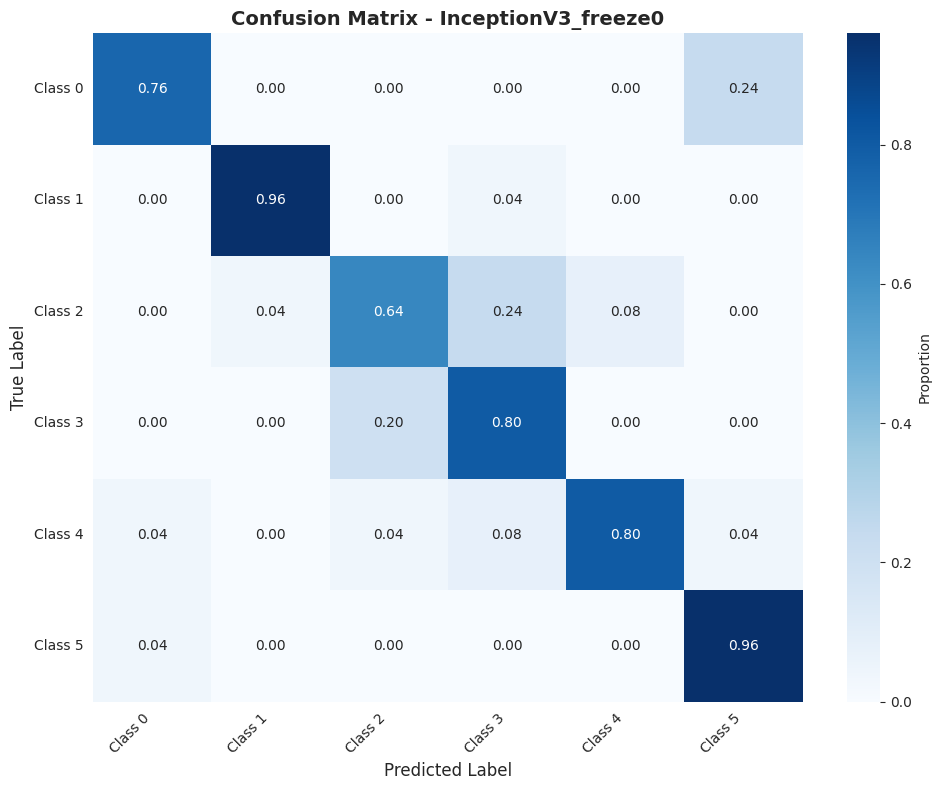

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/InceptionV3_freeze0_confusion_matrix.png


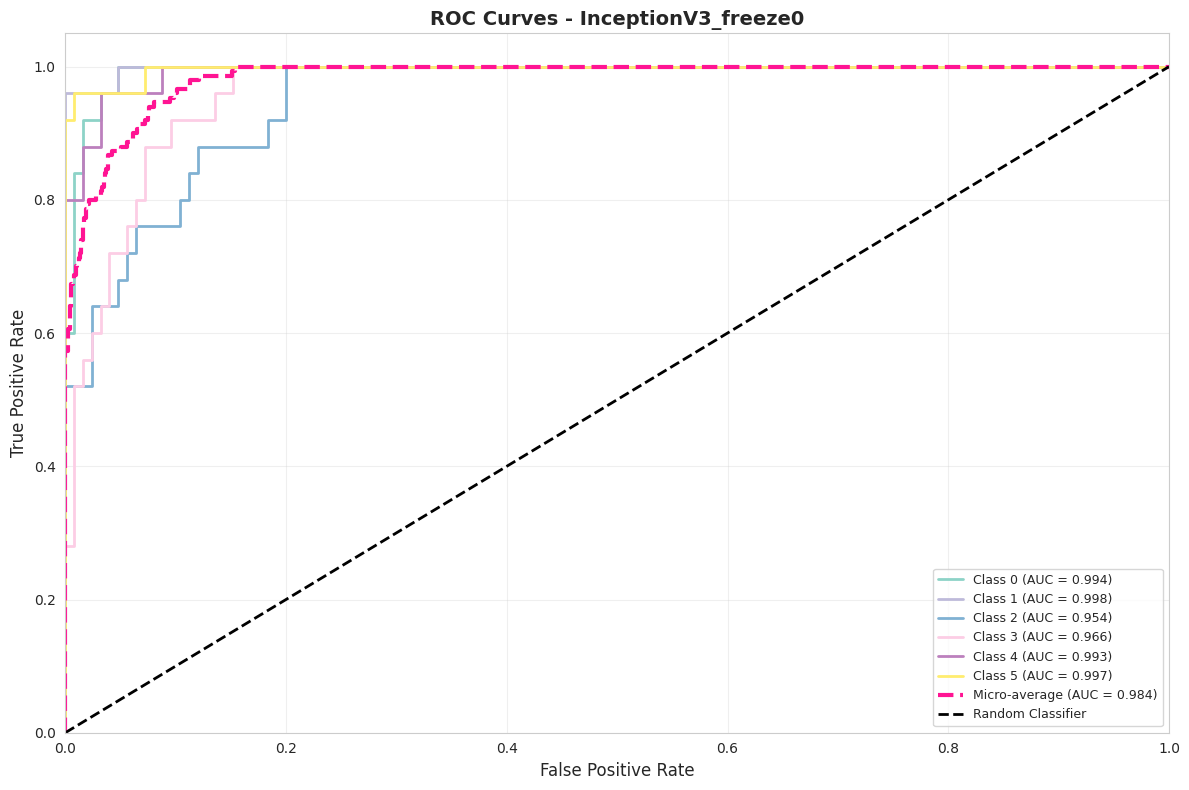

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/InceptionV3_freeze0_roc_curves.png

Evaluating: InceptionV3_freeze100
  Accuracy:  0.8733
  Precision: 0.8937
  Recall:    0.8733
  F1-Score:  0.8721
  ROC AUC (macro): 0.9844


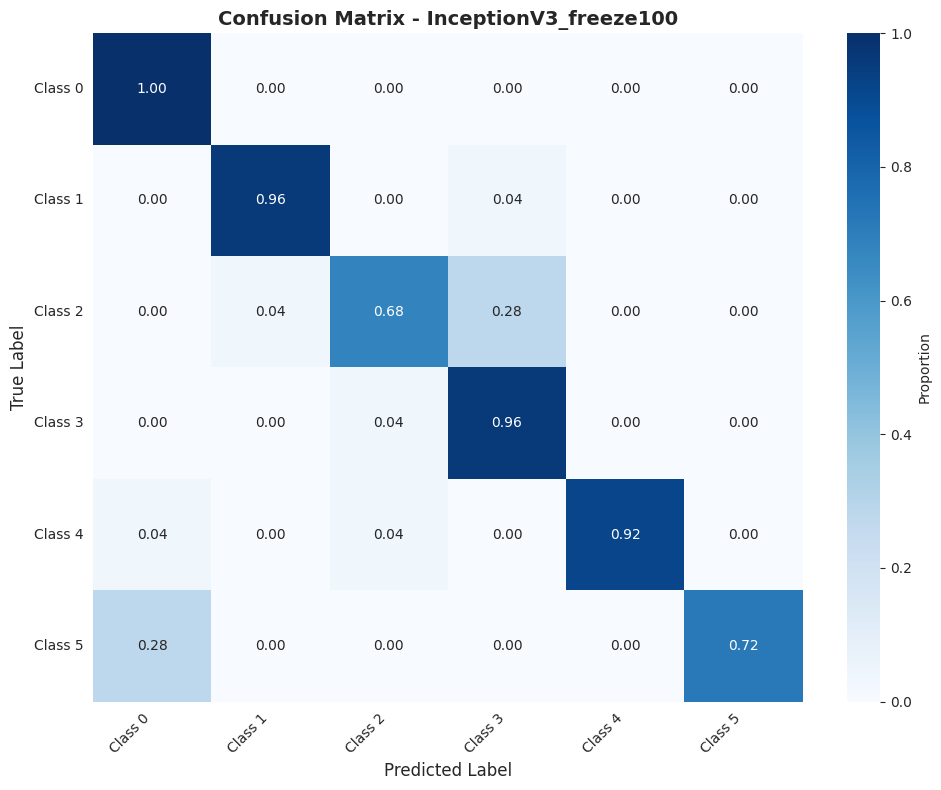

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/InceptionV3_freeze100_confusion_matrix.png


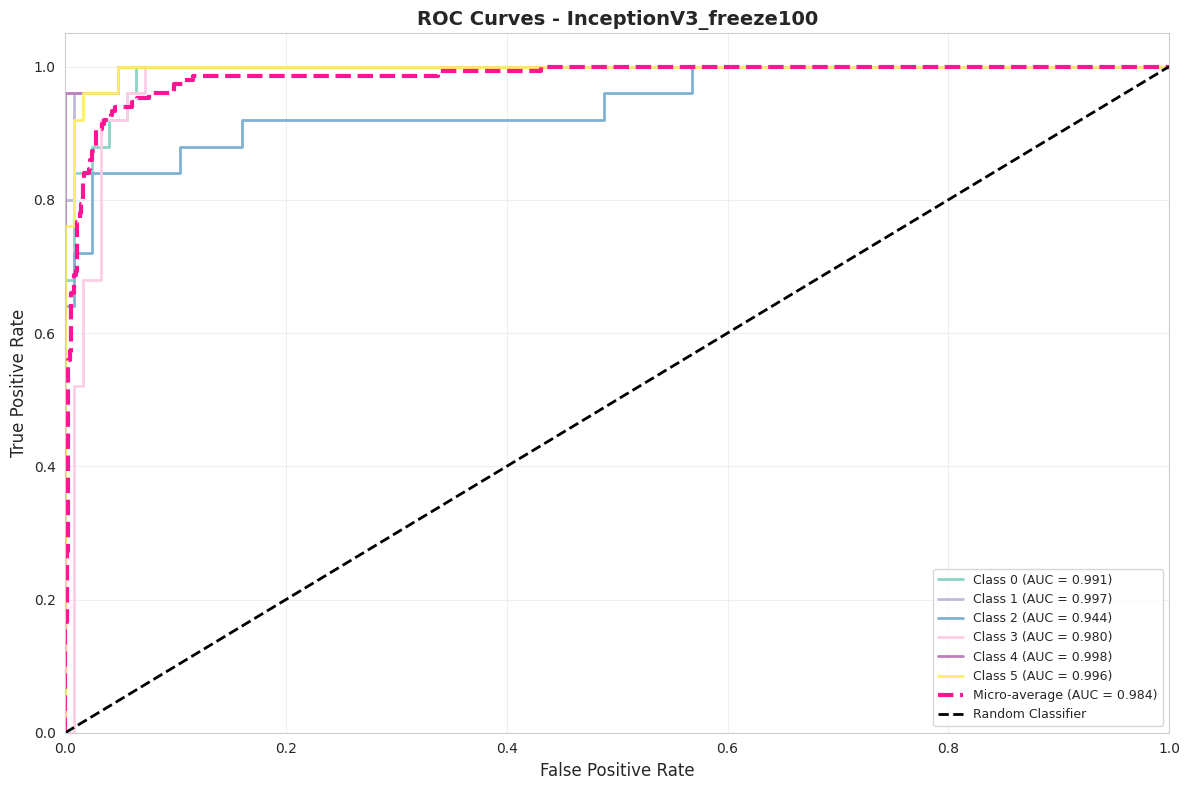

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/InceptionV3_freeze100_roc_curves.png

Evaluating: InceptionV3_freeze25
  Accuracy:  0.8933
  Precision: 0.8989
  Recall:    0.8933
  F1-Score:  0.8946
  ROC AUC (macro): 0.9843


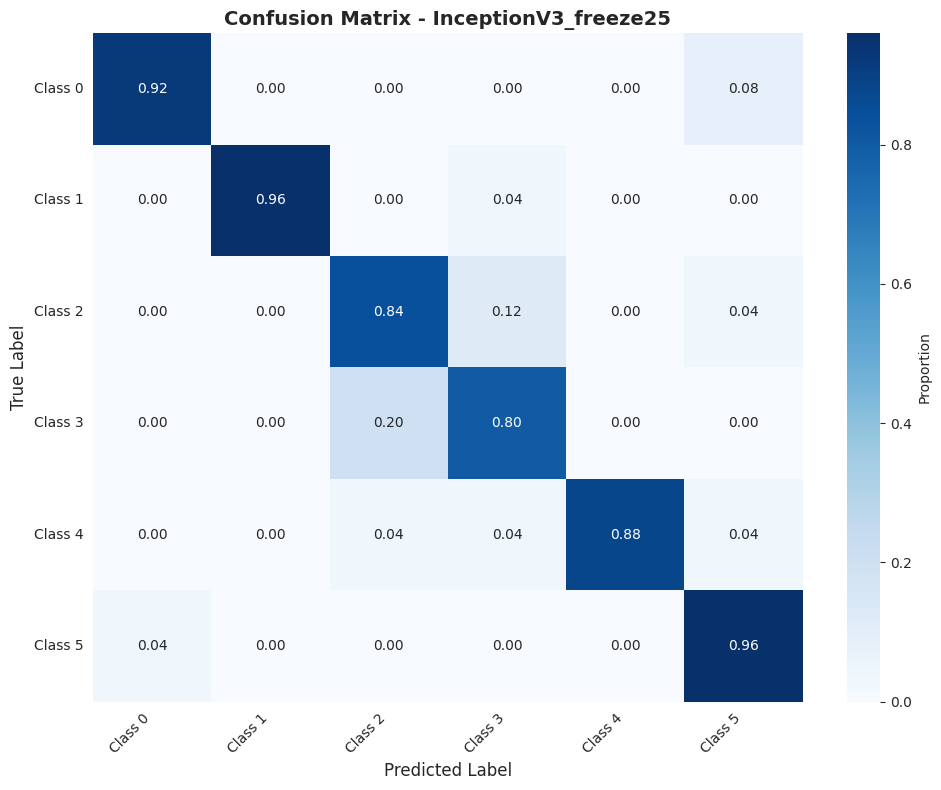

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/InceptionV3_freeze25_confusion_matrix.png


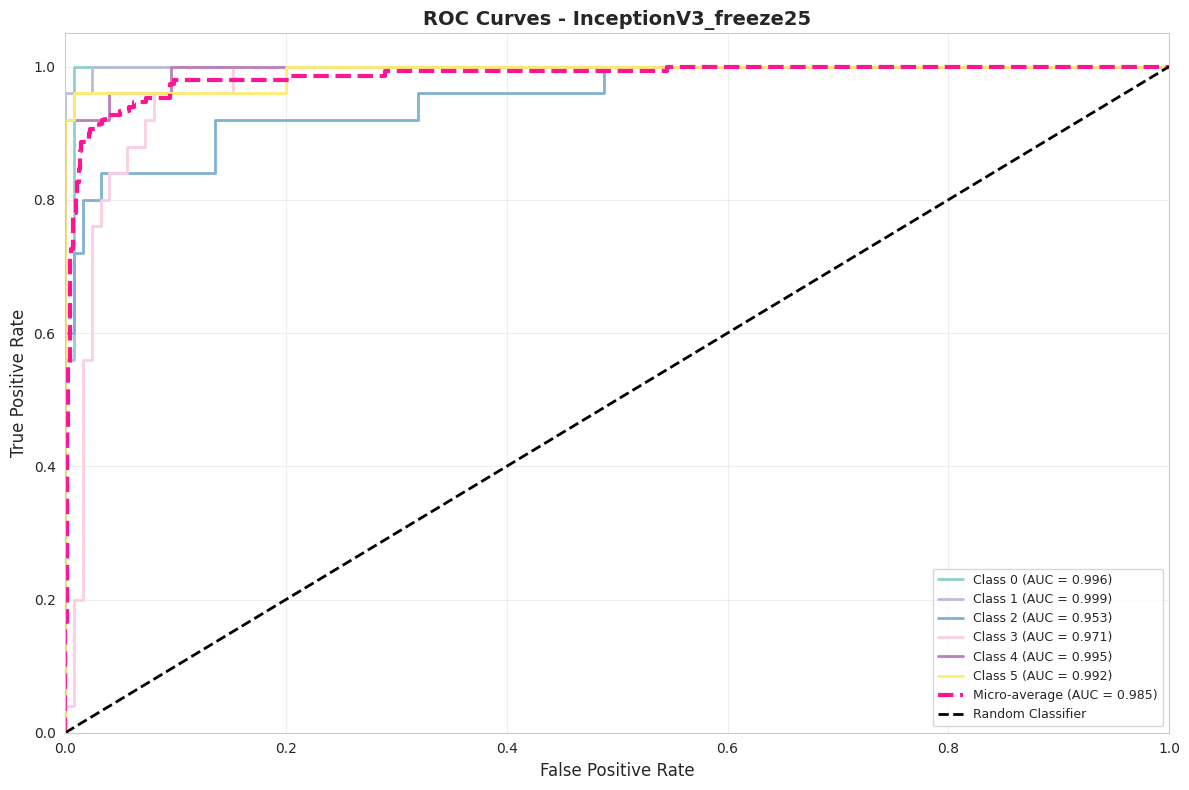

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/InceptionV3_freeze25_roc_curves.png

Evaluating: InceptionV3_freeze50
  Accuracy:  0.8600
  Precision: 0.8661
  Recall:    0.8600
  F1-Score:  0.8608
  ROC AUC (macro): 0.9810


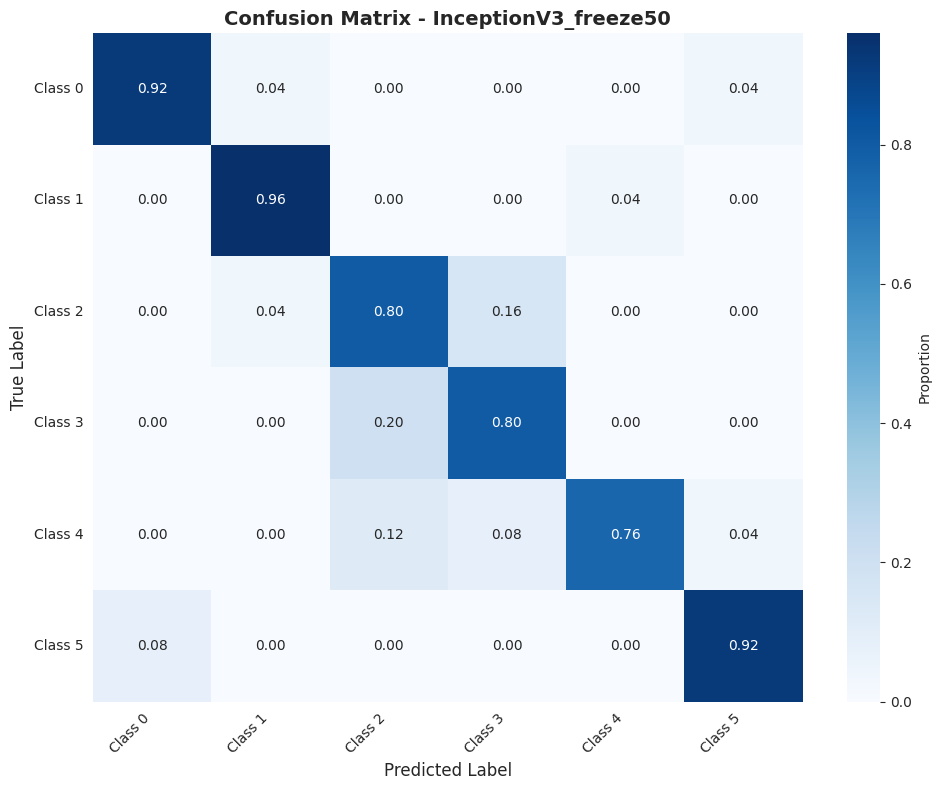

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/InceptionV3_freeze50_confusion_matrix.png


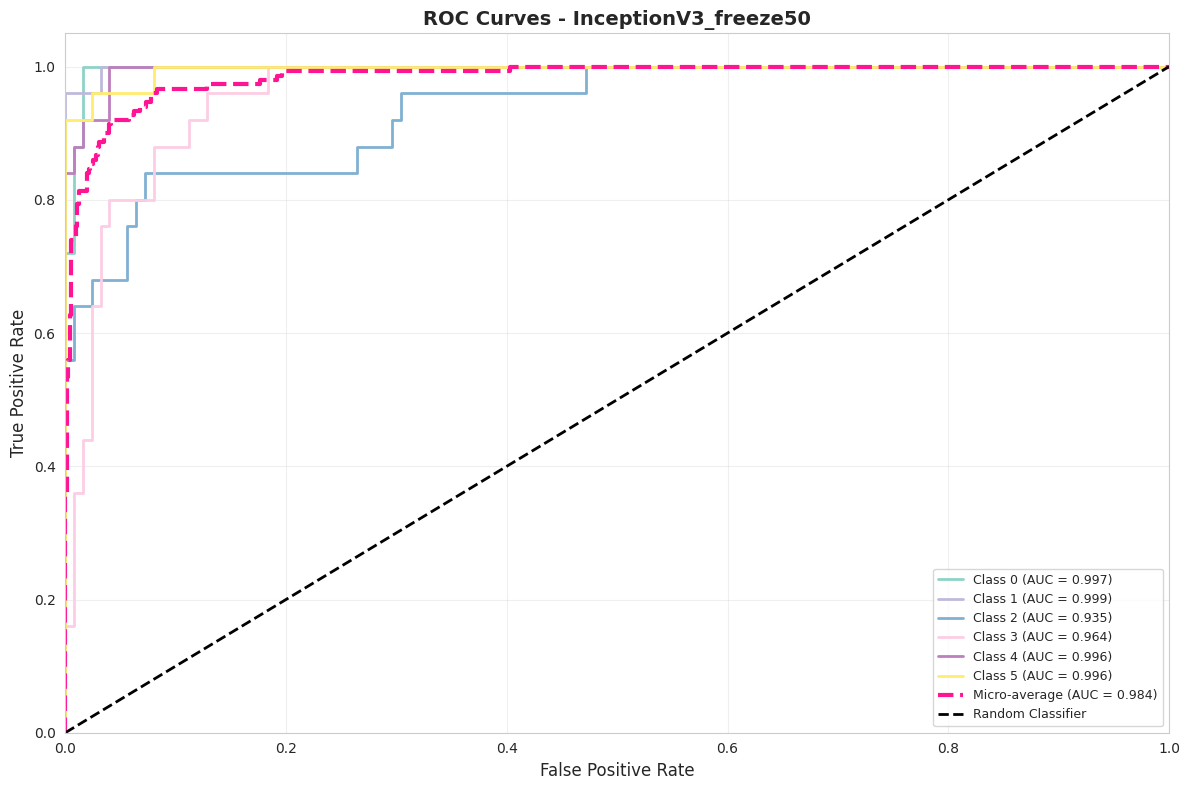

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/InceptionV3_freeze50_roc_curves.png

Evaluating: InceptionV3_freeze75
  Accuracy:  0.8800
  Precision: 0.8963
  Recall:    0.8800
  F1-Score:  0.8821
  ROC AUC (macro): 0.9882


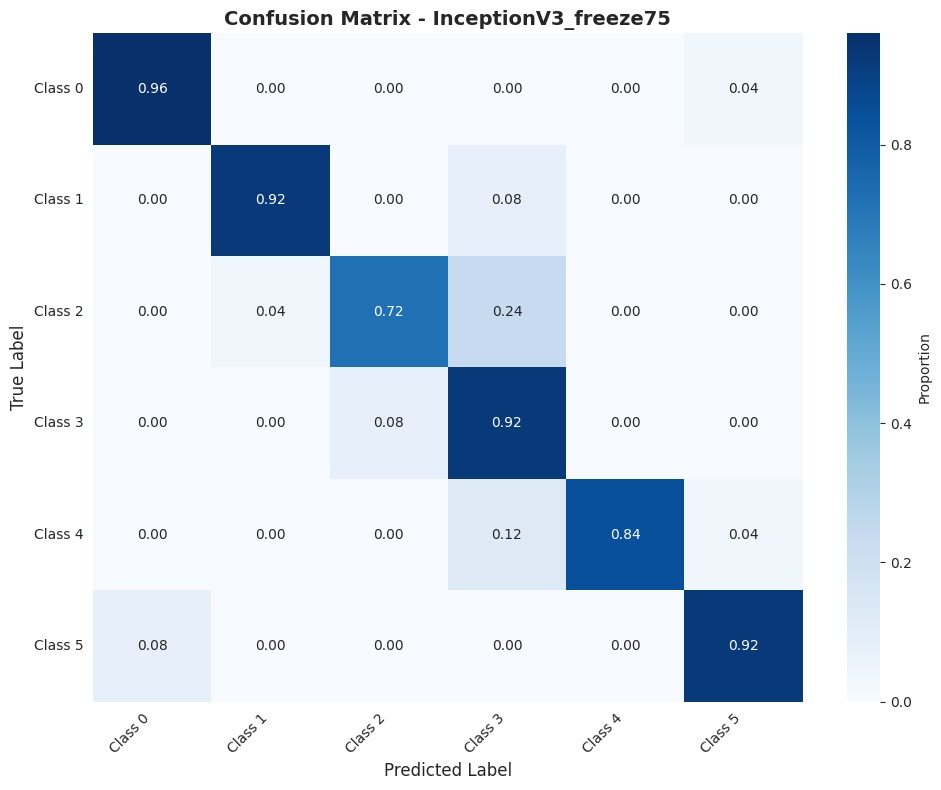

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/InceptionV3_freeze75_confusion_matrix.png


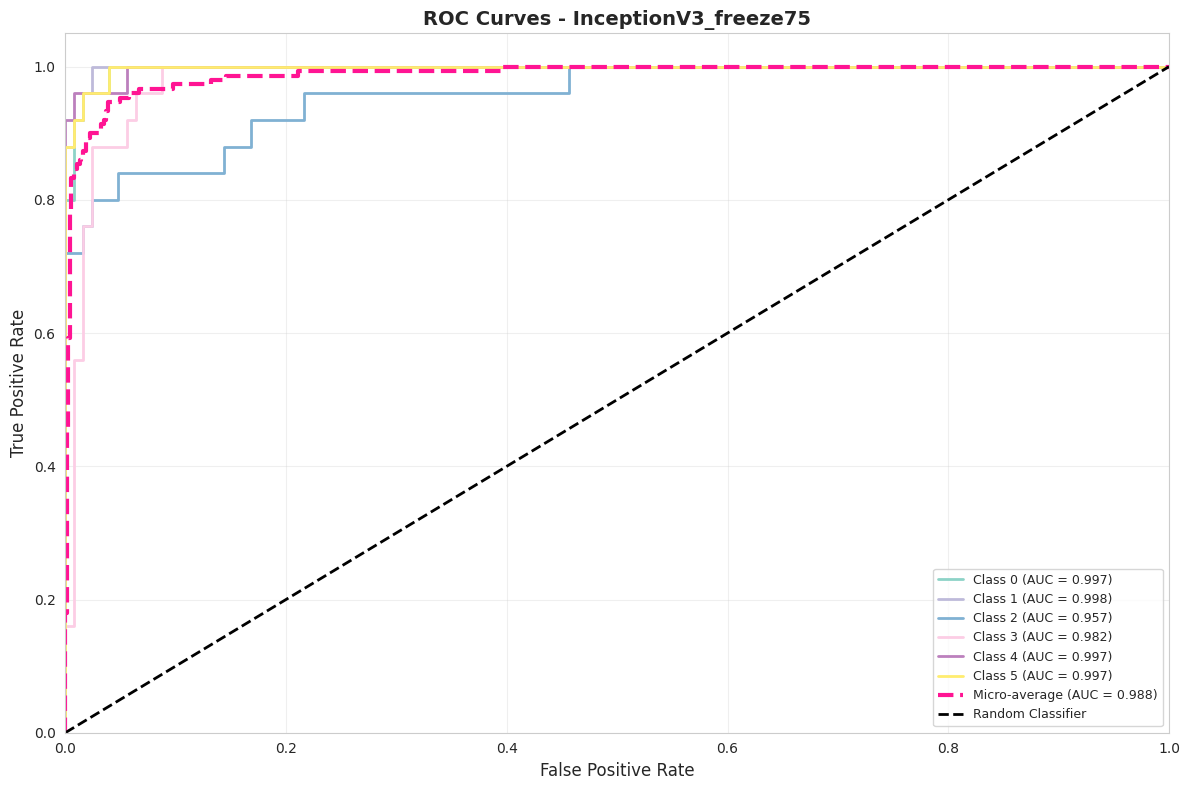

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/InceptionV3_freeze75_roc_curves.png

Evaluating: ResNet50_freeze100
  Accuracy:  0.4200
  Precision: 0.5420
  Recall:    0.4200
  F1-Score:  0.3672
  ROC AUC (macro): 0.8363


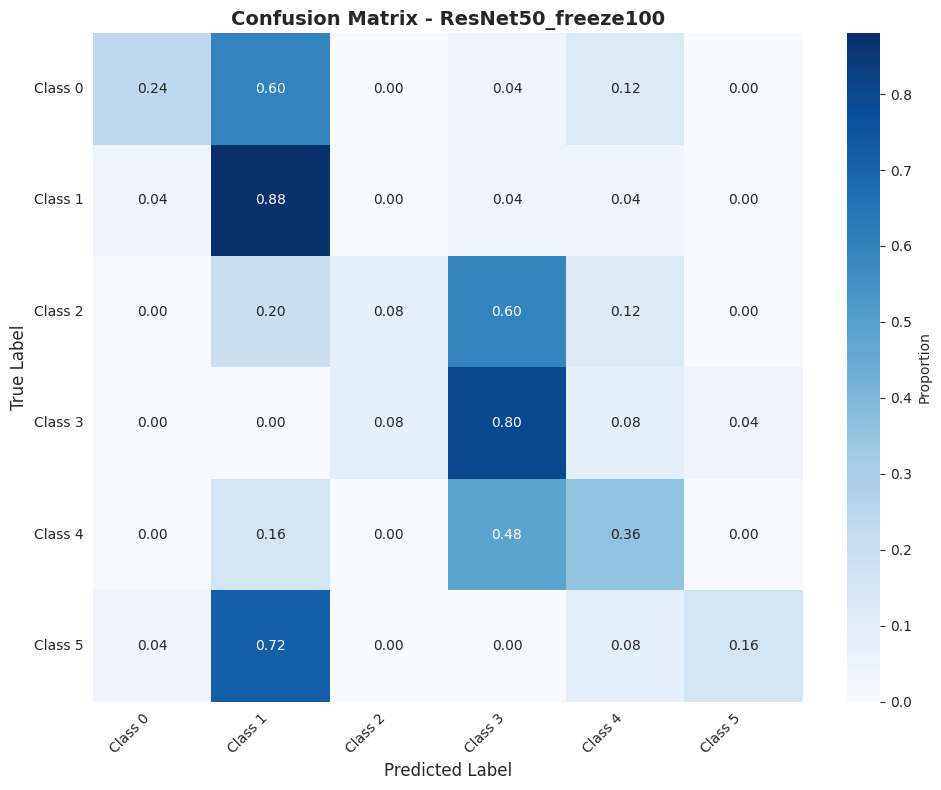

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/ResNet50_freeze100_confusion_matrix.png


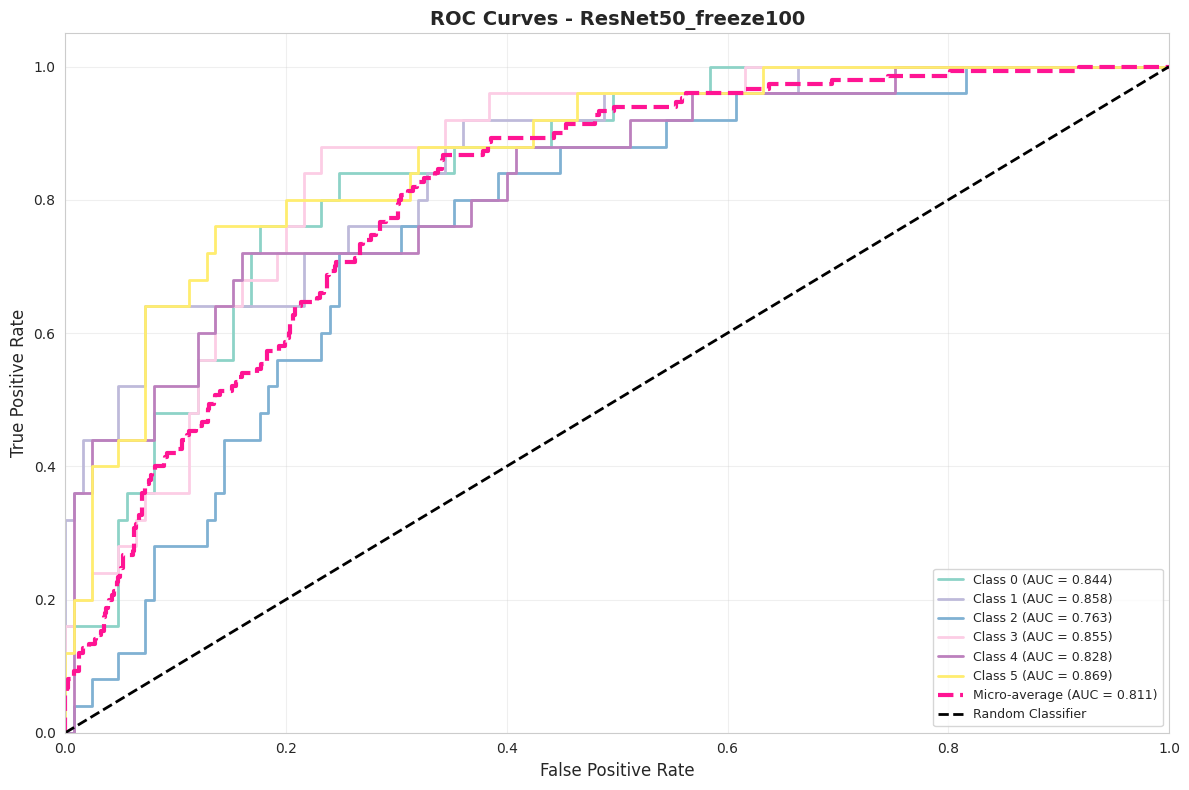

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/ResNet50_freeze100_roc_curves.png

Evaluating: ResNet50_freeze25
  Accuracy:  0.2667
  Precision: 0.2931
  Recall:    0.2667
  F1-Score:  0.2021
  ROC AUC (macro): 0.6632


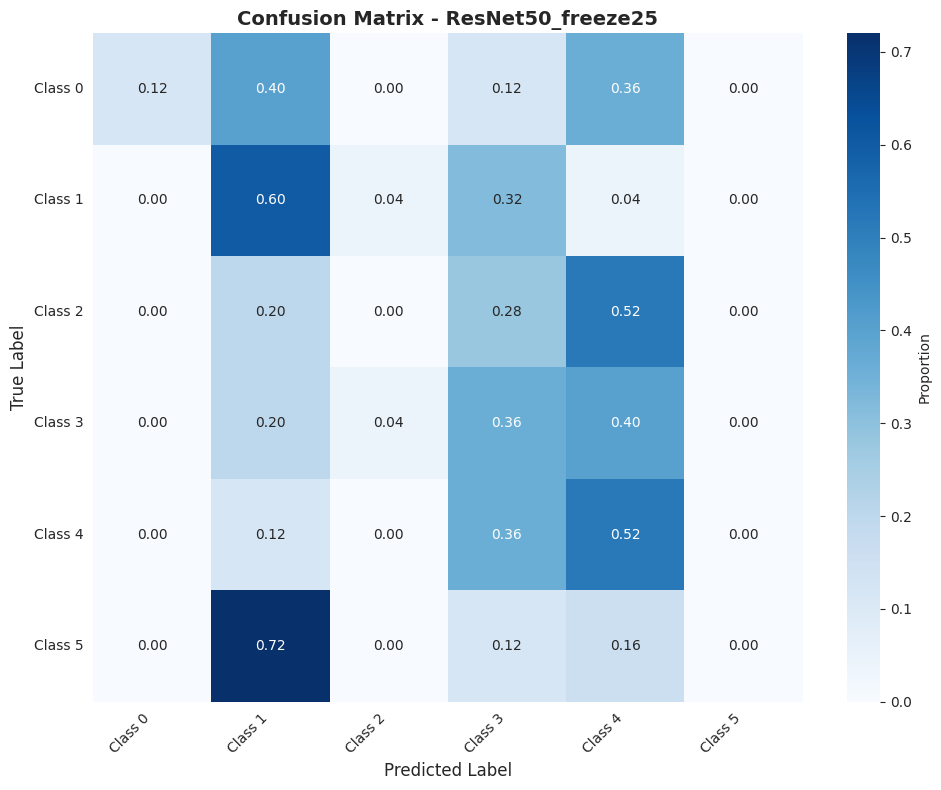

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/ResNet50_freeze25_confusion_matrix.png


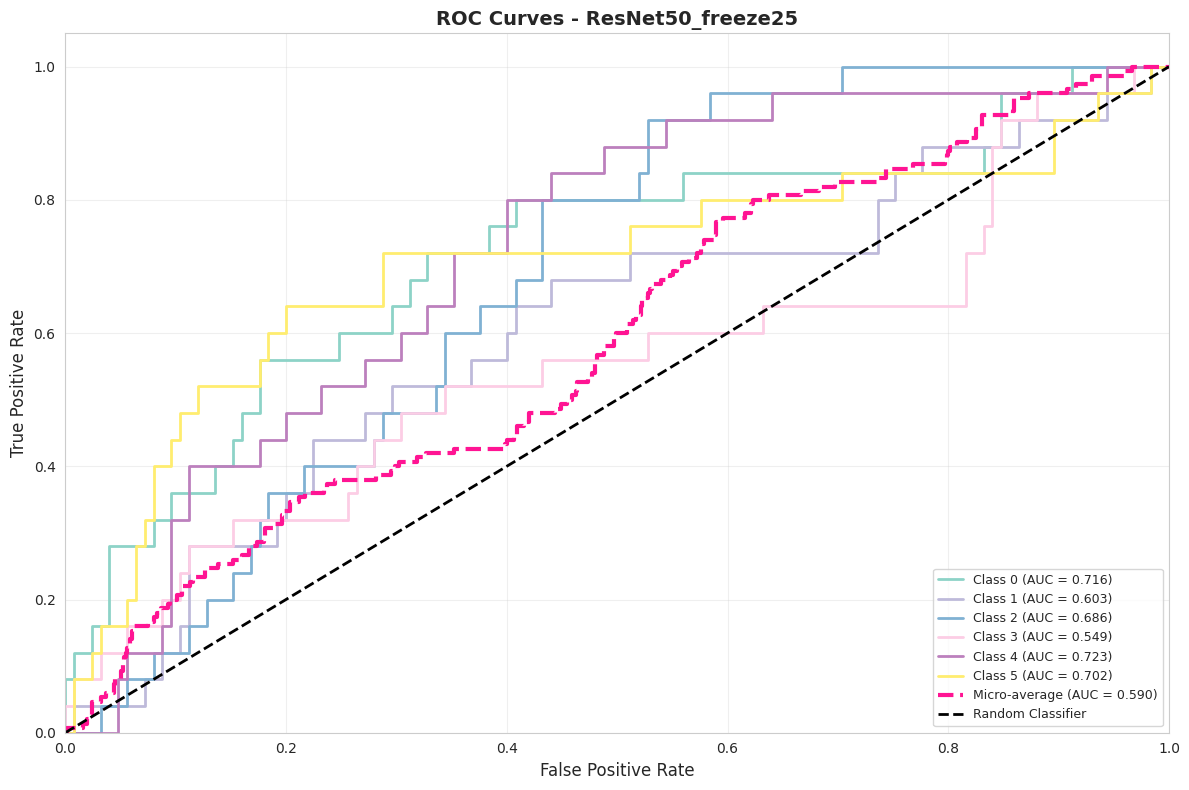

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/ResNet50_freeze25_roc_curves.png

Evaluating: ResNet50_freeze50
  Accuracy:  0.3667
  Precision: 0.4184
  Recall:    0.3667
  F1-Score:  0.3266
  ROC AUC (macro): 0.8181


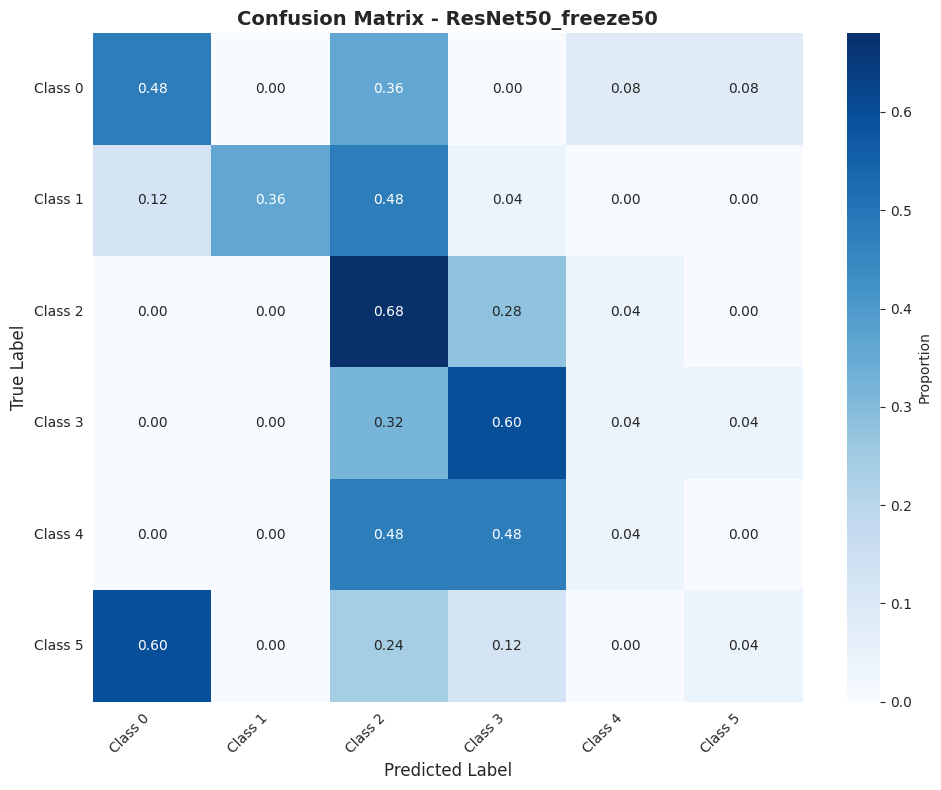

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/ResNet50_freeze50_confusion_matrix.png


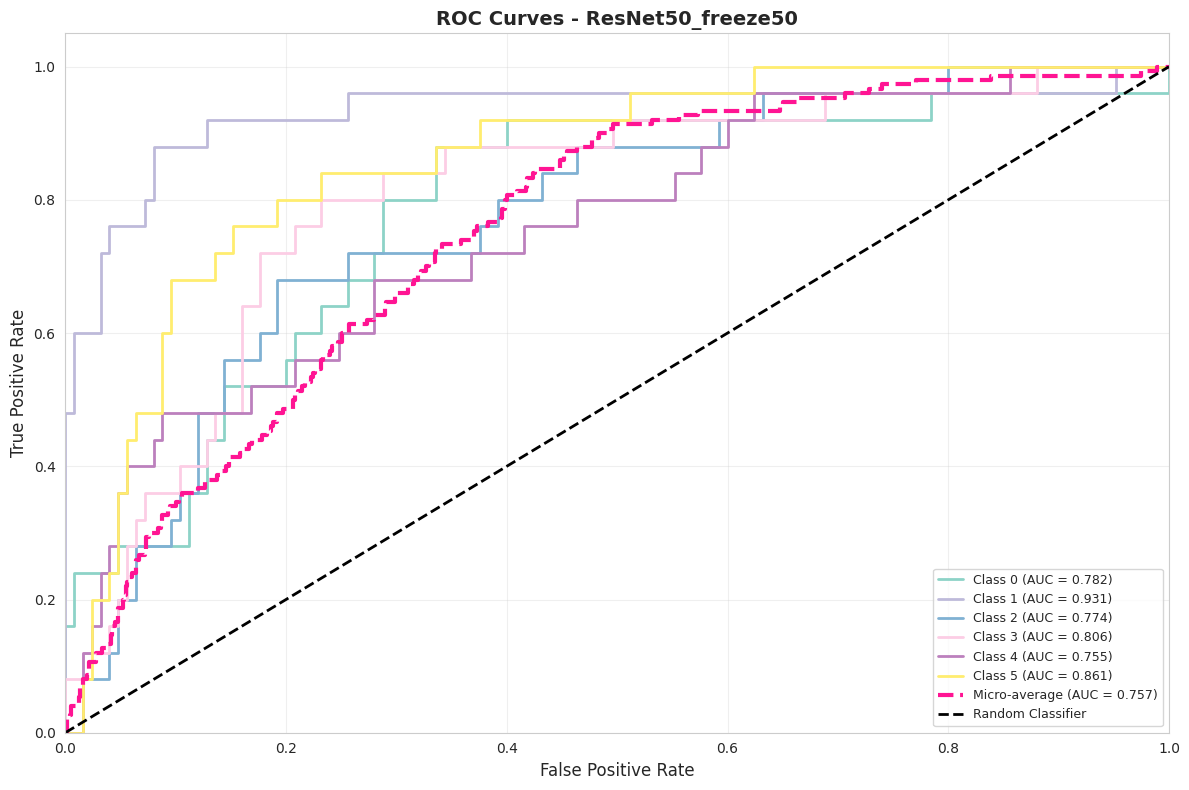

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/ResNet50_freeze50_roc_curves.png

Evaluating: ResNet50_freeze75
  Accuracy:  0.3667
  Precision: 0.2489
  Recall:    0.3667
  F1-Score:  0.2662
  ROC AUC (macro): 0.8510


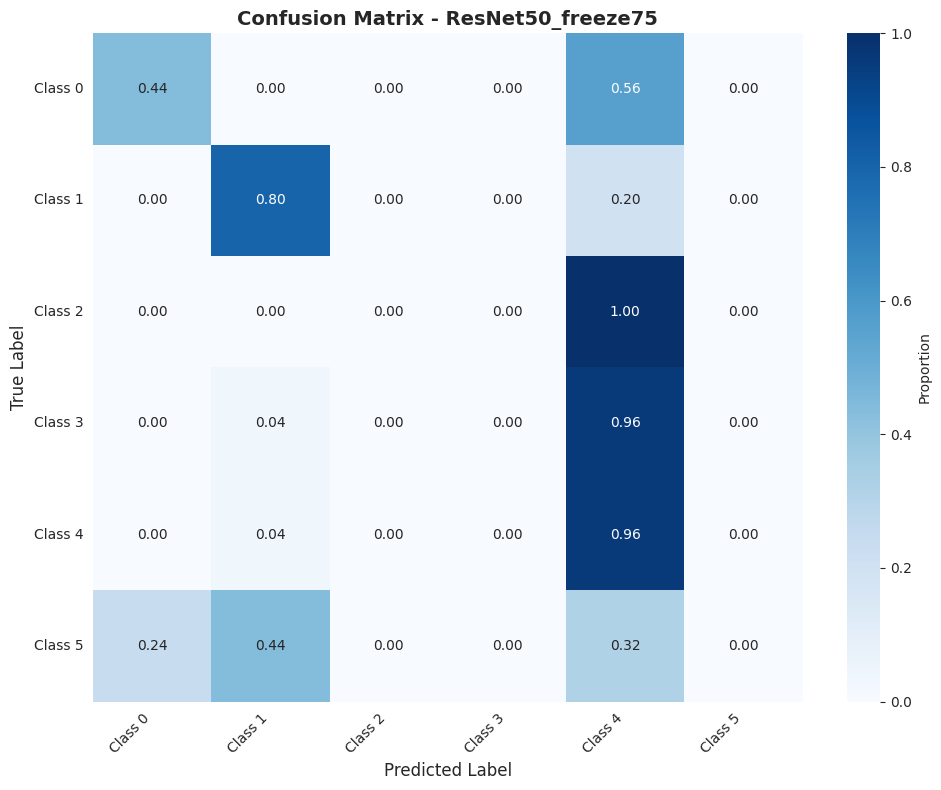

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/ResNet50_freeze75_confusion_matrix.png


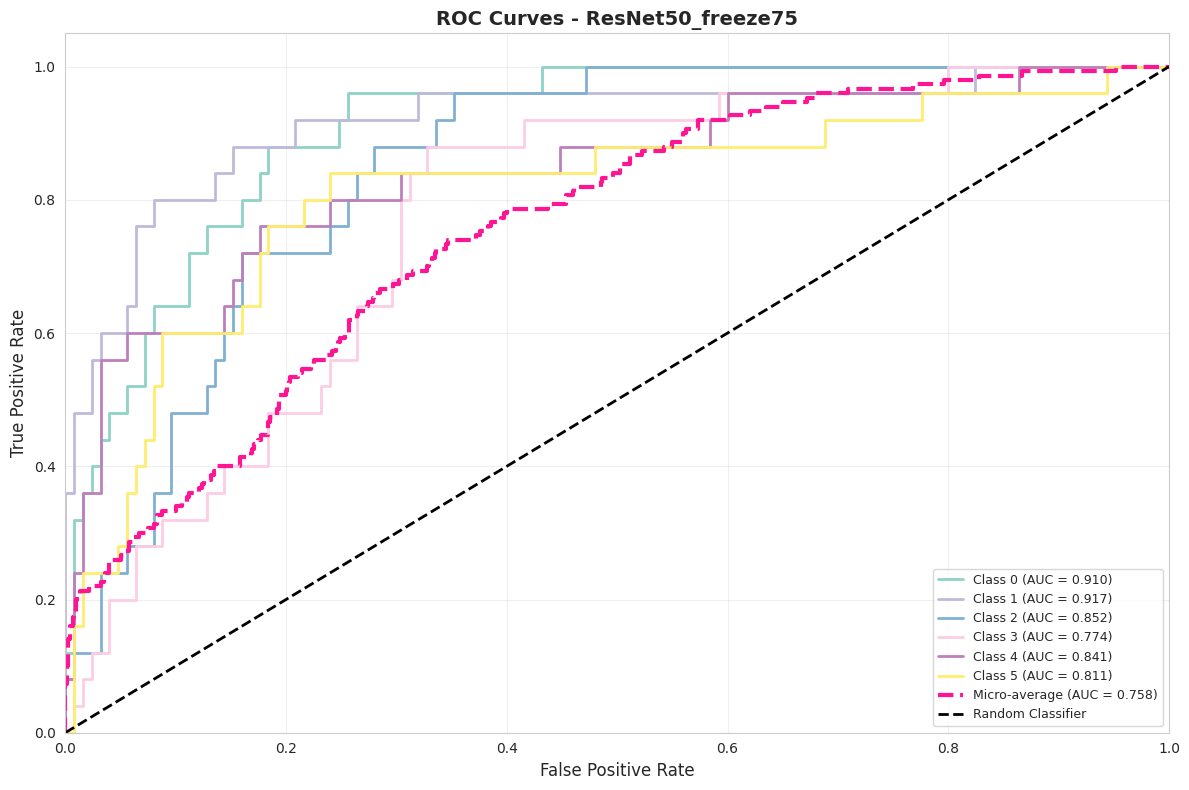

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/ResNet50_freeze75_roc_curves.png

Evaluating: VGG16_freeze0
  Accuracy:  0.8667
  Precision: 0.8759
  Recall:    0.8667
  F1-Score:  0.8666
  ROC AUC (macro): 0.9725


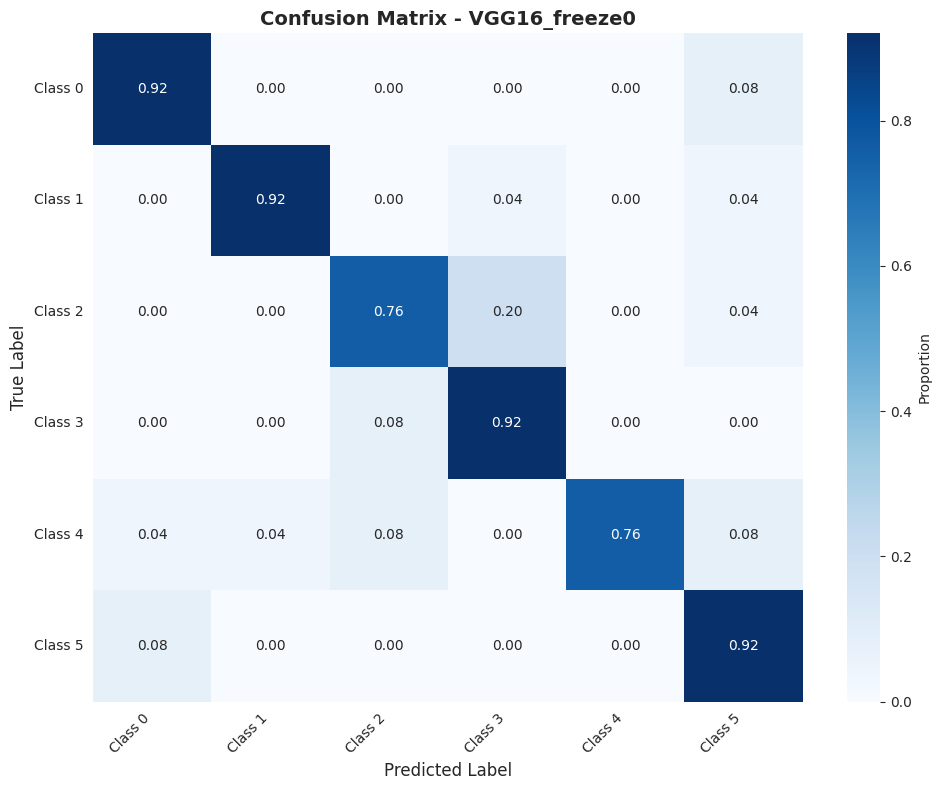

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/VGG16_freeze0_confusion_matrix.png


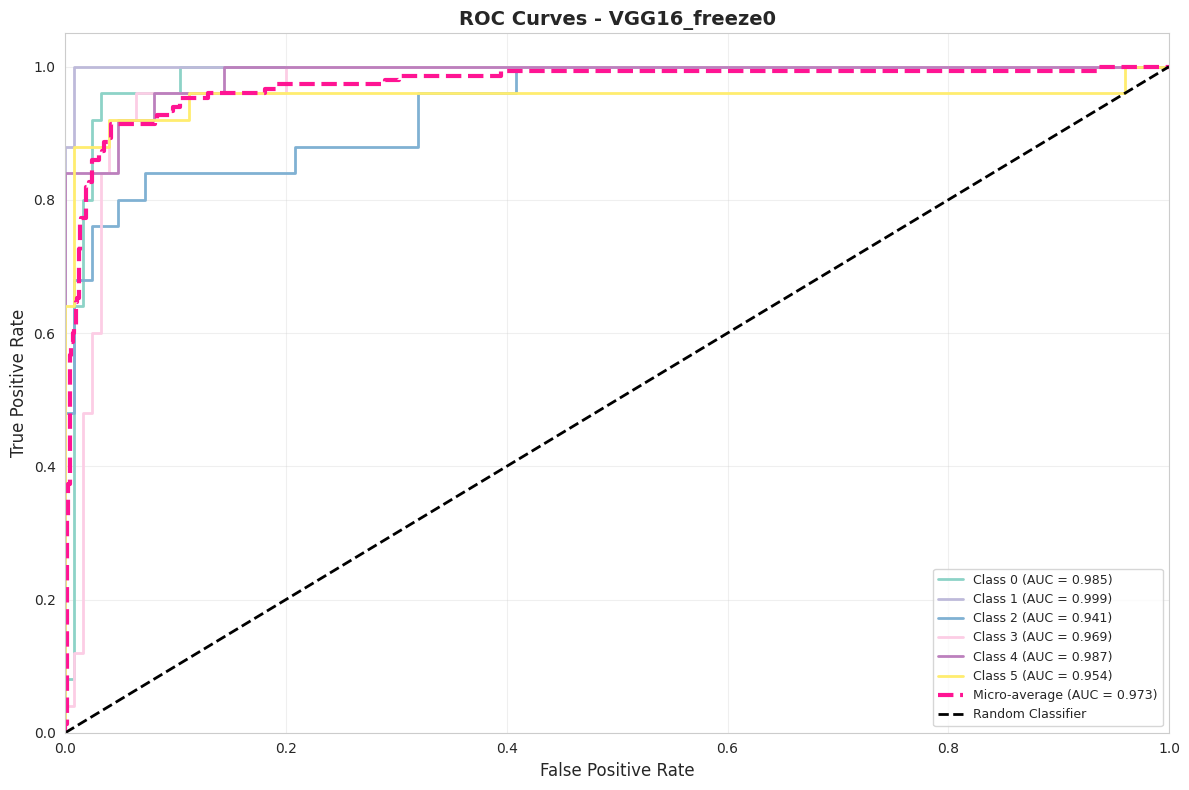

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/VGG16_freeze0_roc_curves.png

Evaluating: VGG16_freeze100
  Accuracy:  0.8267
  Precision: 0.8287
  Recall:    0.8267
  F1-Score:  0.8271
  ROC AUC (macro): 0.9761


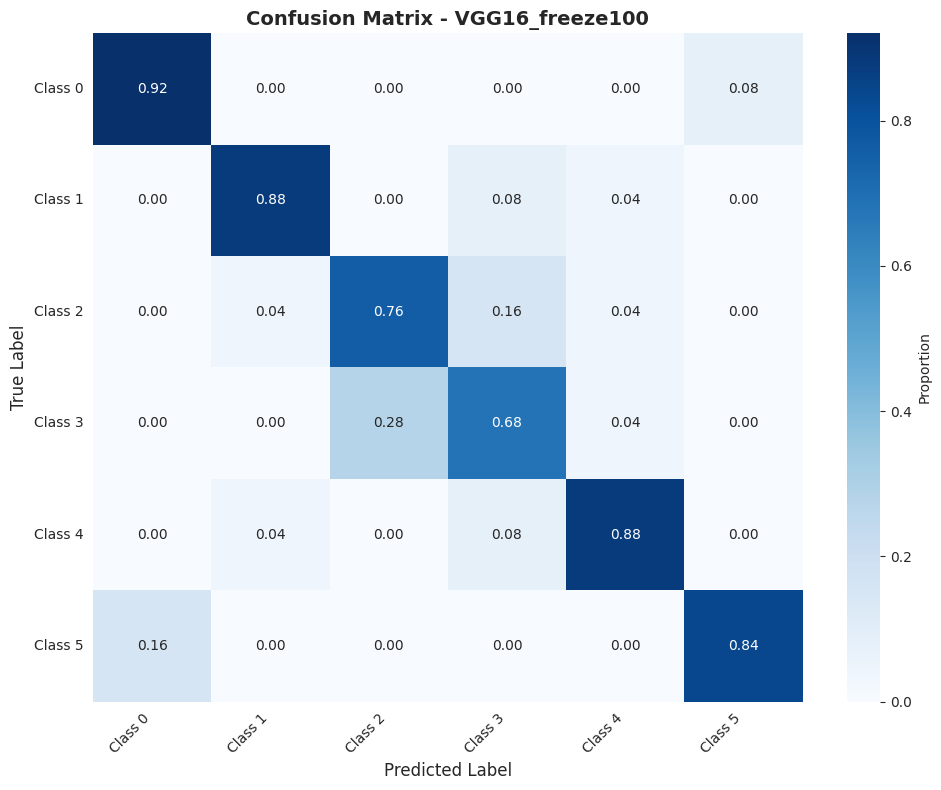

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/VGG16_freeze100_confusion_matrix.png


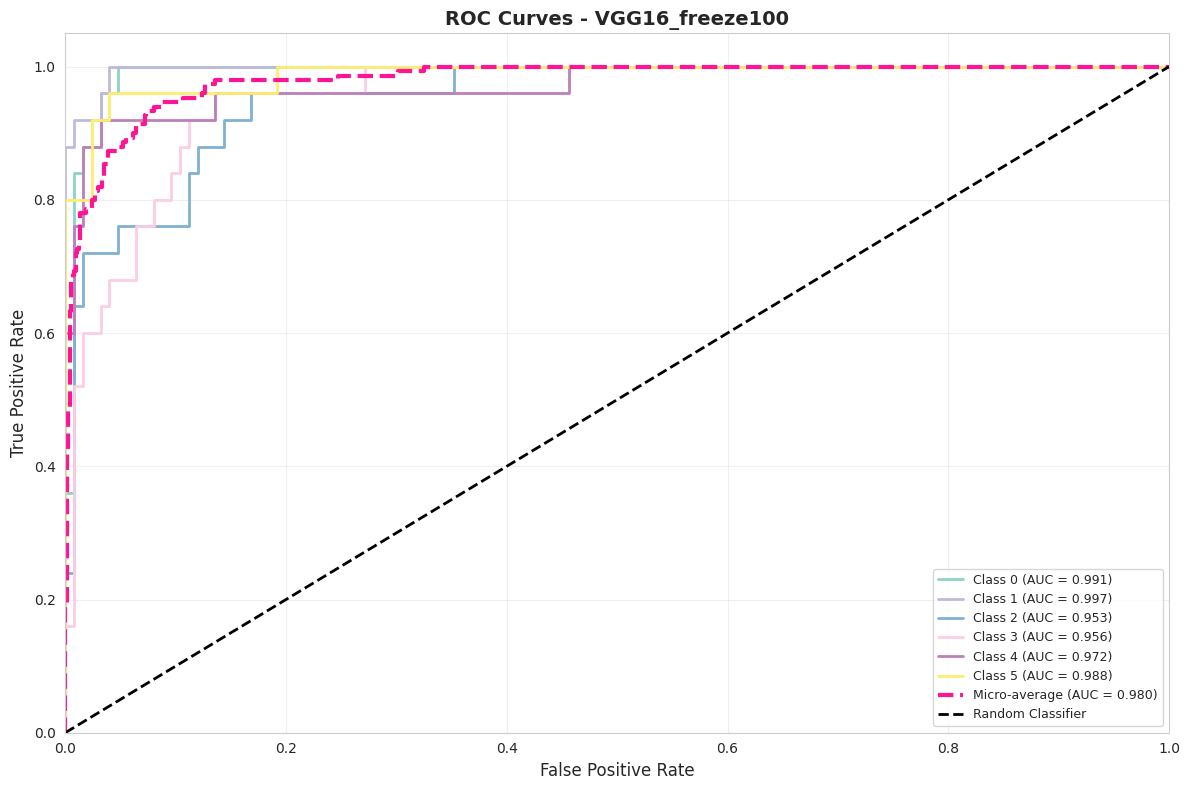

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/VGG16_freeze100_roc_curves.png

Evaluating: VGG16_freeze25
  Accuracy:  0.8200
  Precision: 0.8249
  Recall:    0.8200
  F1-Score:  0.8148
  ROC AUC (macro): 0.9743


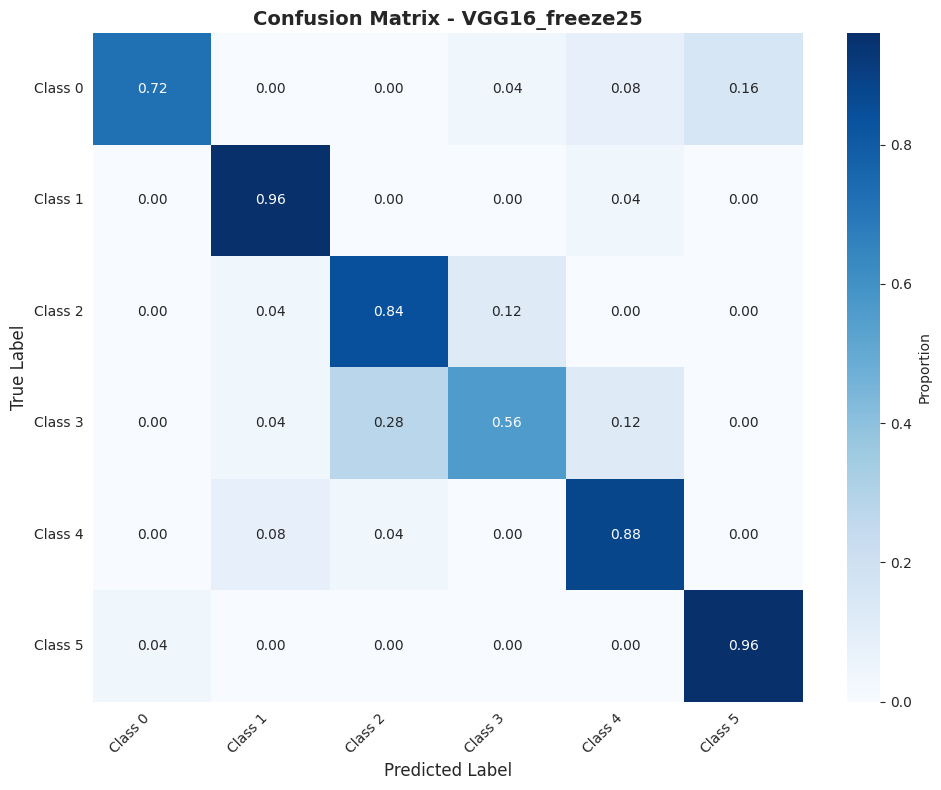

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/VGG16_freeze25_confusion_matrix.png


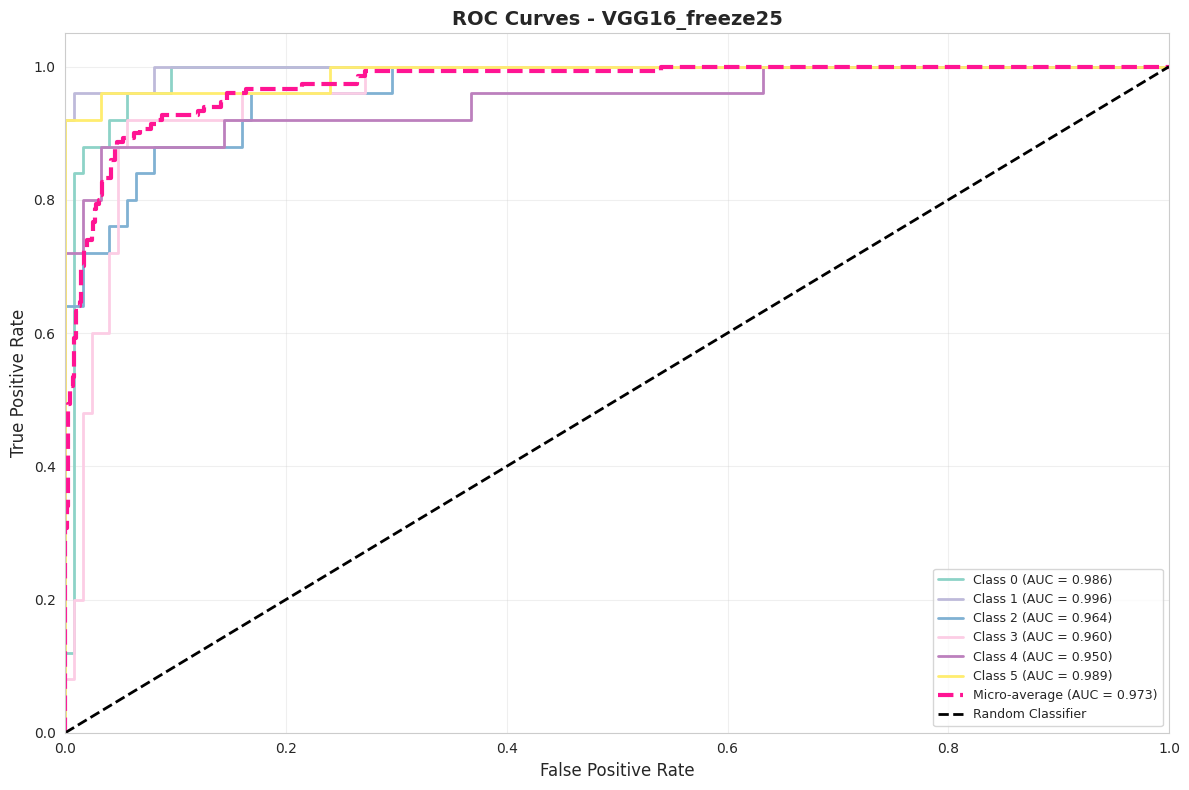

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/VGG16_freeze25_roc_curves.png

Evaluating: VGG16_freeze50
  Accuracy:  0.8467
  Precision: 0.8485
  Recall:    0.8467
  F1-Score:  0.8456
  ROC AUC (macro): 0.9601


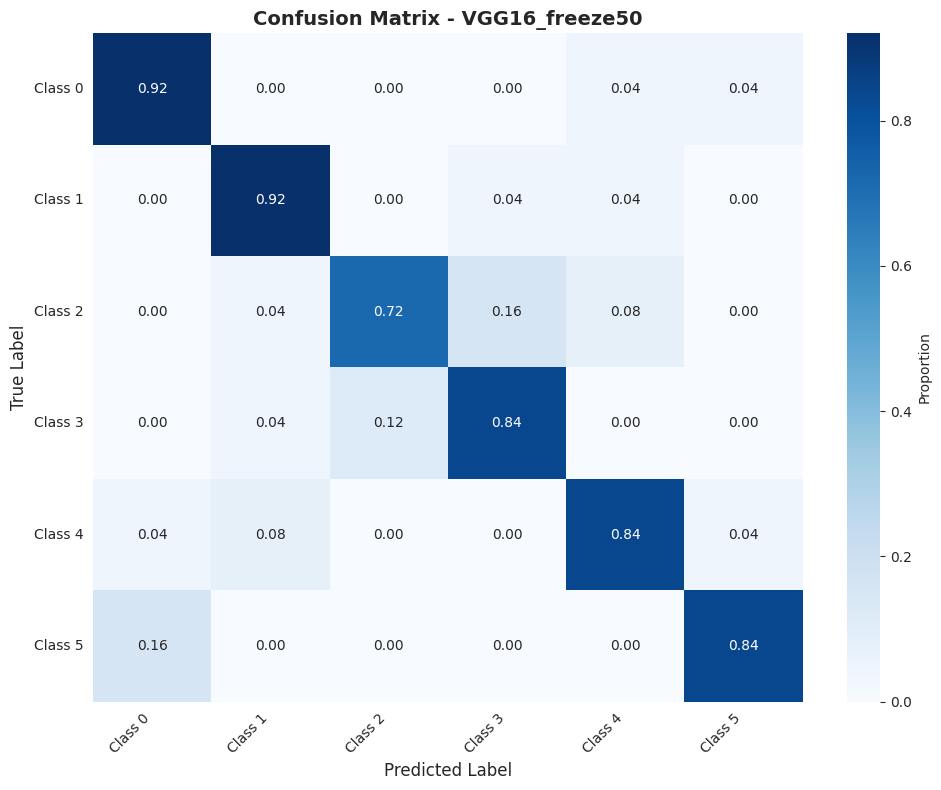

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/VGG16_freeze50_confusion_matrix.png


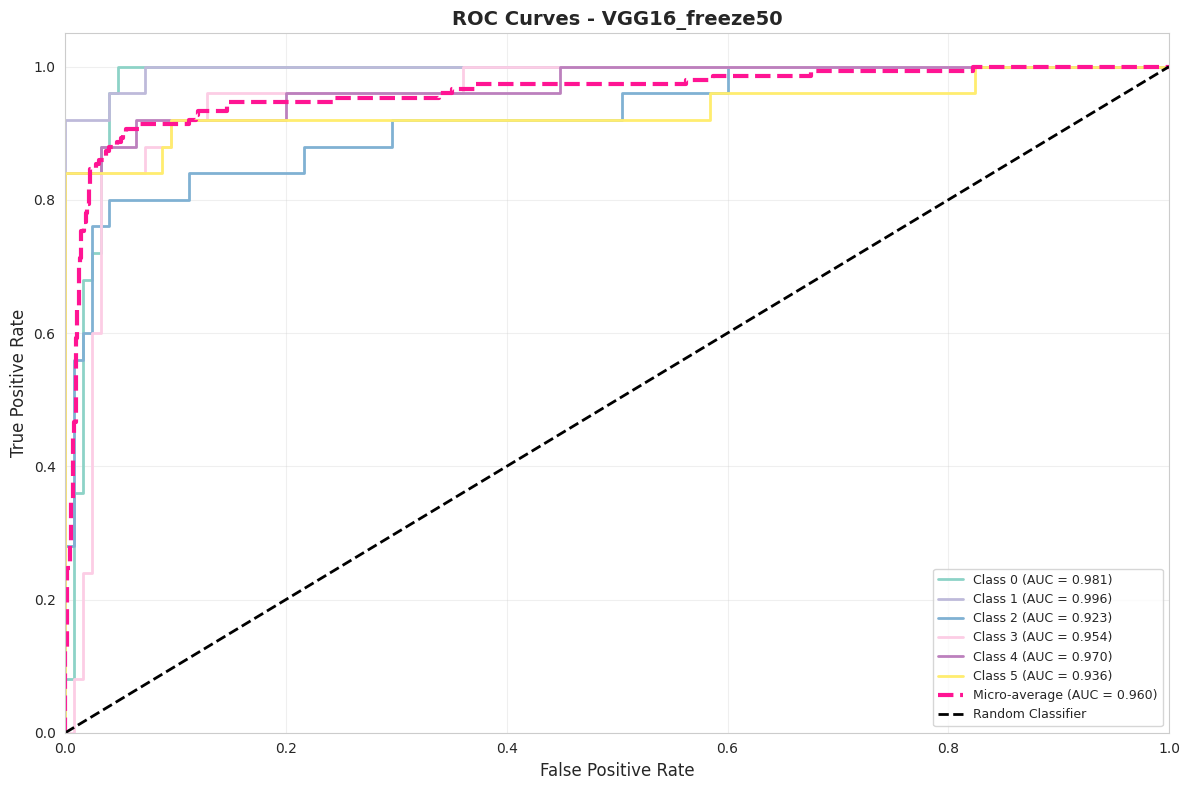

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/VGG16_freeze50_roc_curves.png

Evaluating: VGG16_freeze75
  Accuracy:  0.8600
  Precision: 0.8747
  Recall:    0.8600
  F1-Score:  0.8568
  ROC AUC (macro): 0.9791


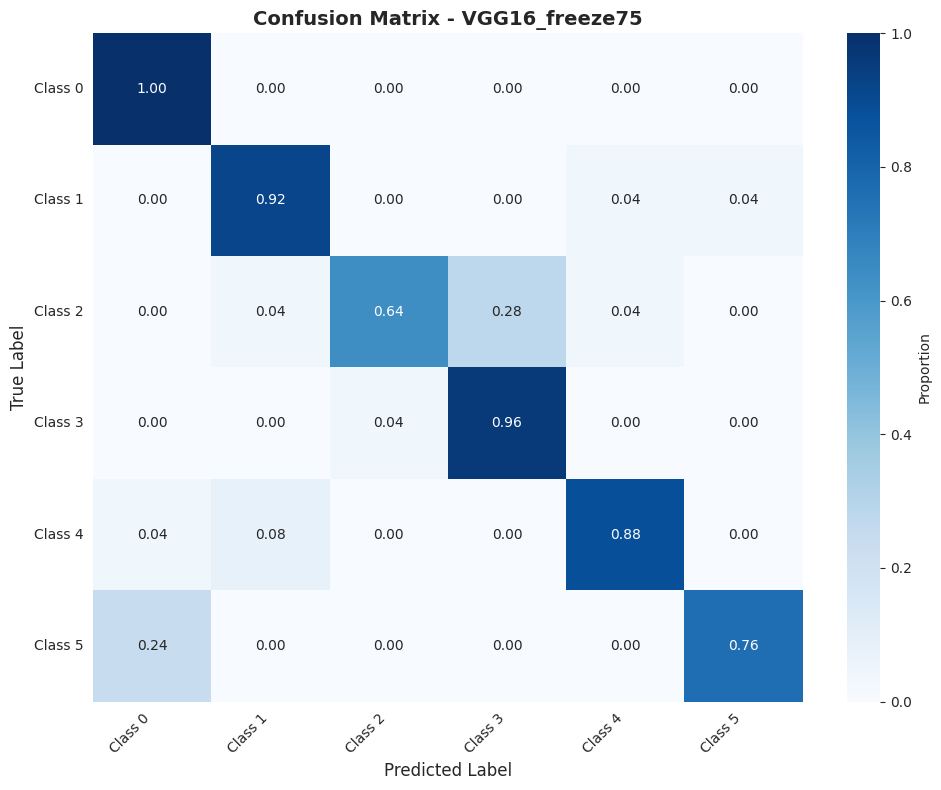

  ✓ Confusion matrix saved: outputs_part2/evaluation/confusion_matrices/VGG16_freeze75_confusion_matrix.png


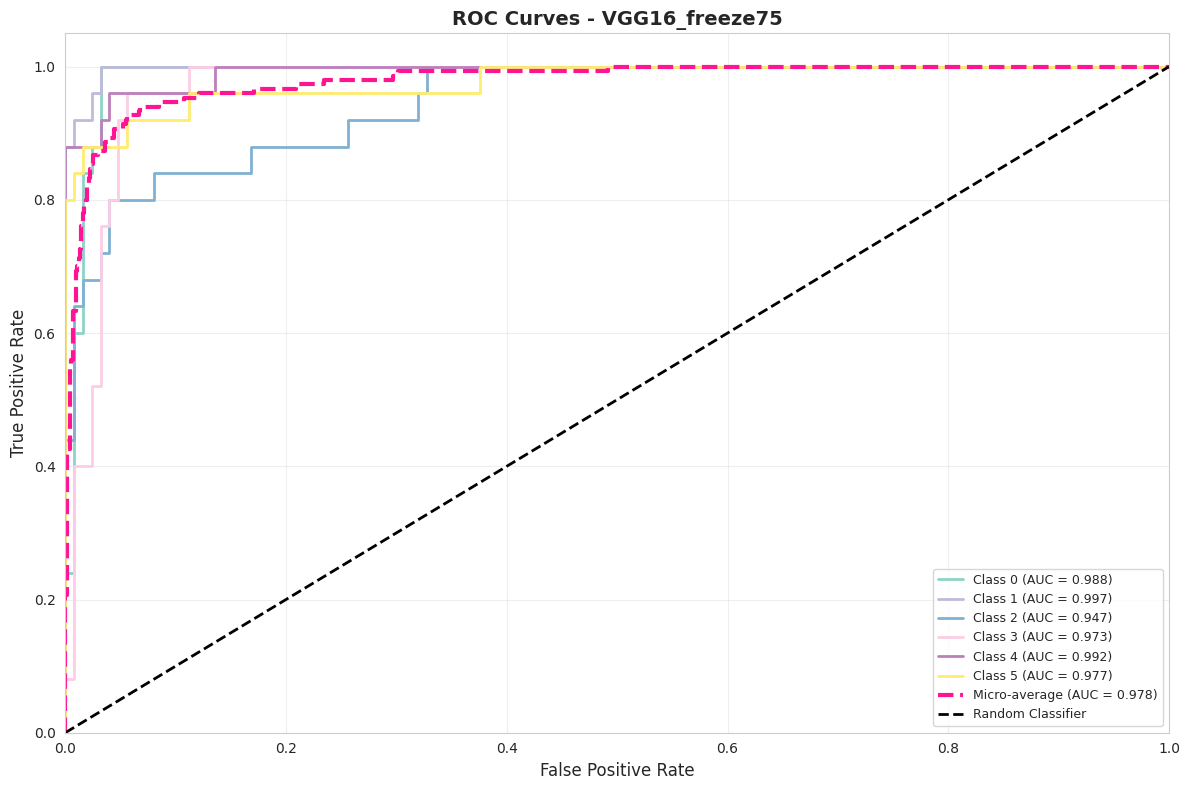

  ✓ ROC curves saved: outputs_part2/evaluation/roc_curves/VGG16_freeze75_roc_curves.png

Creating comparison visualizations...

✓ Metrics table saved: outputs_part2/evaluation/metrics/metrics_comparison_table.csv


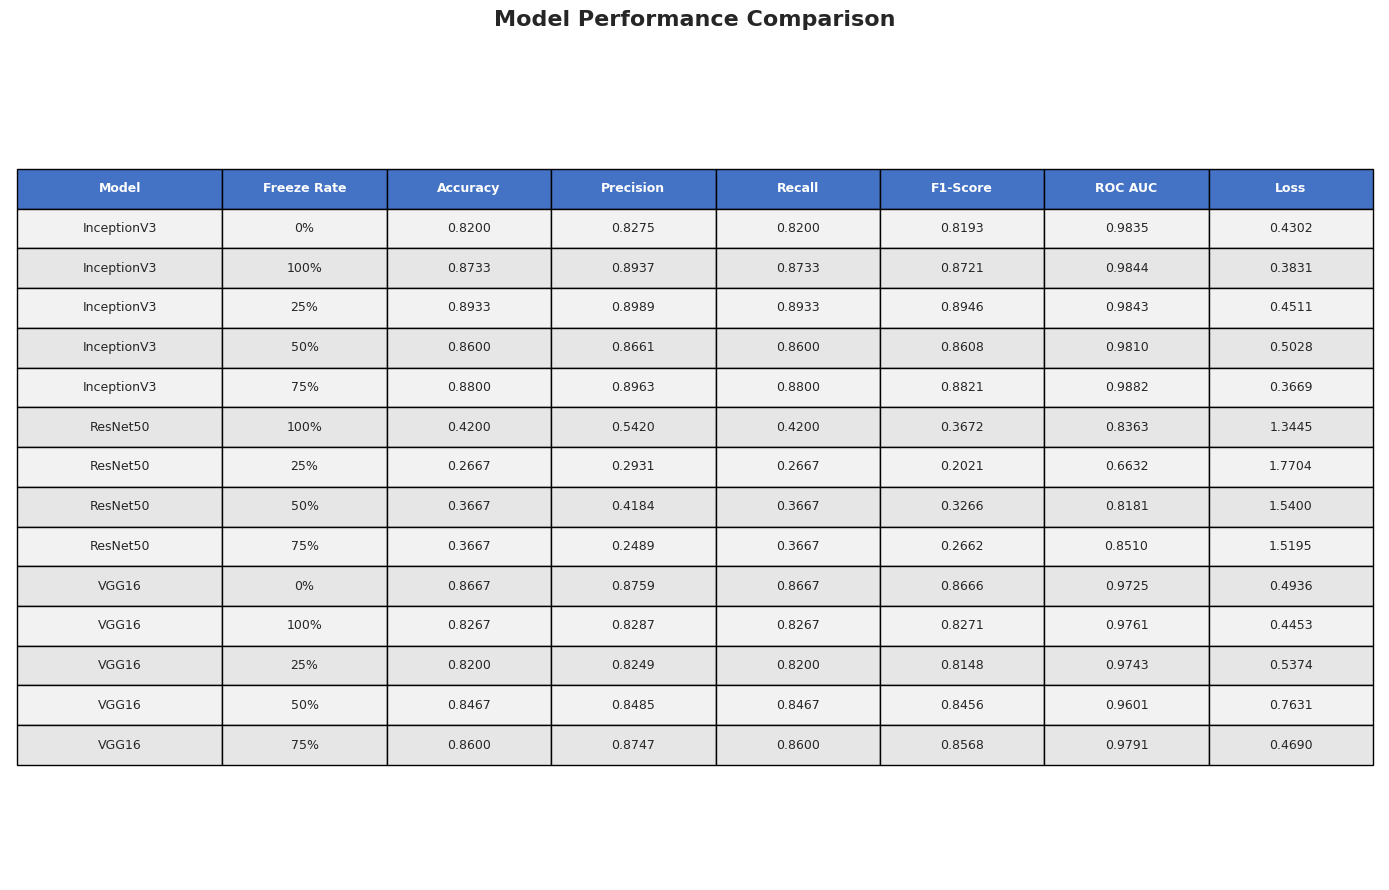

✓ Metrics comparison plot saved: outputs_part2/evaluation/metrics/metrics_comparison_table.png


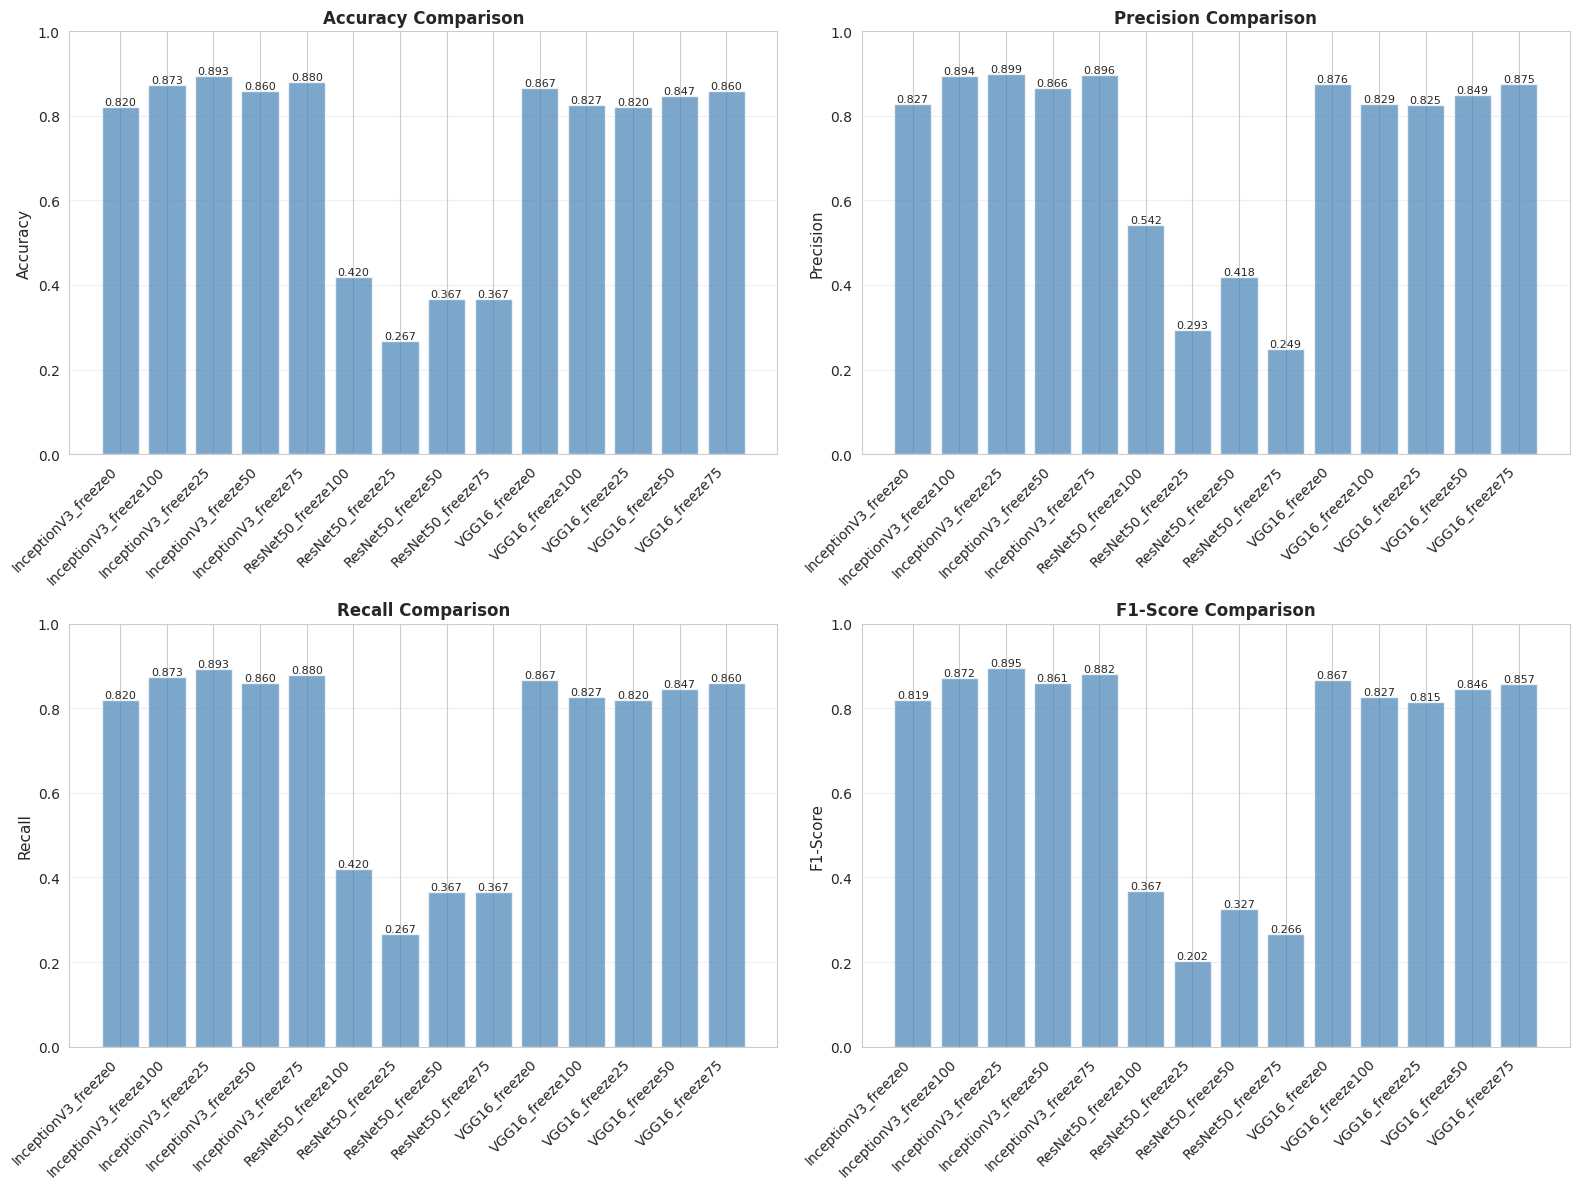

✓ Metrics comparison charts saved

✓ EVALUATION COMPLETE

Results saved in: outputs_part2/evaluation/
  - Confusion matrices: confusion_matrices/
  - ROC curves: roc_curves/
  - Metrics: metrics/

TOP PERFORMING MODELS
                Model  Accuracy  Precision   Recall  F1-Score  ROC AUC (Macro)  ROC AUC (Weighted)     Loss
 InceptionV3_freeze25  0.893333   0.898876 0.893333  0.894648         0.984320            0.984320 0.451070
 InceptionV3_freeze75  0.880000   0.896313 0.880000  0.882109         0.988213            0.988213 0.366950
InceptionV3_freeze100  0.873333   0.893719 0.873333  0.872074         0.984427            0.984427 0.383060
        VGG16_freeze0  0.866667   0.875874 0.866667  0.866624         0.972533            0.972533 0.493596
       VGG16_freeze75  0.860000   0.874650 0.860000  0.856768         0.979147            0.979147 0.468982
 InceptionV3_freeze50  0.860000   0.866099 0.860000  0.860775         0.980960            0.980960 0.502820
       VGG16_freeze50  0.

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Create output directories
os.makedirs('outputs_part2/evaluation', exist_ok=True)
os.makedirs('outputs_part2/evaluation/confusion_matrices', exist_ok=True)
os.makedirs('outputs_part2/evaluation/roc_curves', exist_ok=True)
os.makedirs('outputs_part2/evaluation/metrics', exist_ok=True)

def load_existing_models(models_dir='outputs_part2/models'):
    """
    Load all existing models from the models directory.
    
    Returns:
        Dictionary with model names as keys and loaded models as values
    """
    model_files = glob.glob(os.path.join(models_dir, '*.h5'))
    models = {}
    
    print(f"Found {len(model_files)} model(s) in {models_dir}")
    for model_path in sorted(model_files):
        model_name = os.path.basename(model_path).replace('.h5', '')
        try:
            model = tf.keras.models.load_model(model_path)
            models[model_name] = model
            print(f"  ✓ Loaded: {model_name}")
        except Exception as e:
            print(f"  ✗ Failed to load {model_name}: {str(e)}")
    
    return models

def evaluate_model(model, model_name, X_test, y_test, class_names):
    """
    Comprehensive evaluation of a single model.
    
    Args:
        model: Trained Keras model
        model_name: Name of the model
        X_test: Test features
        y_test: Test labels (one-hot encoded)
        class_names: List of class names
        
    Returns:
        Dictionary containing all metrics
    """
    print(f"\nEvaluating: {model_name}")
    print("="*60)
    
    # Get predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)
    
    # Calculate basic metrics
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    precision = precision_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
    recall = recall_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
    f1 = f1_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
    
    # Per-class metrics
    precision_per_class = precision_score(y_test_classes, y_pred_classes, average=None, zero_division=0)
    recall_per_class = recall_score(y_test_classes, y_pred_classes, average=None, zero_division=0)
    f1_per_class = f1_score(y_test_classes, y_pred_classes, average=None, zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(y_test_classes, y_pred_classes)
    
    # ROC AUC (macro and per-class)
    try:
        roc_auc_macro = roc_auc_score(y_test, y_pred_proba, average='macro', multi_class='ovr')
        roc_auc_weighted = roc_auc_score(y_test, y_pred_proba, average='weighted', multi_class='ovr')
    except:
        roc_auc_macro = 0.0
        roc_auc_weighted = 0.0
    
    print(f"  Accuracy:  {test_acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC AUC (macro): {roc_auc_macro:.4f}")
    
    return {
        'model_name': model_name,
        'test_loss': test_loss,
        'test_accuracy': test_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc_macro': roc_auc_macro,
        'roc_auc_weighted': roc_auc_weighted,
        'y_pred_proba': y_pred_proba,
        'y_pred_classes': y_pred_classes,
        'y_test_classes': y_test_classes,
        'confusion_matrix': cm,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }

def plot_confusion_matrix(cm, model_name, class_names, save_path):
    """Plot and save confusion matrix."""
    plt.figure(figsize=(10, 8))
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proportion'})
    
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  ✓ Confusion matrix saved: {save_path}")

def plot_roc_curves(y_test, y_pred_proba, model_name, class_names, save_path):
    """Plot and save ROC curves for all classes."""
    n_classes = len(class_names)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot
    plt.figure(figsize=(12, 8))
    
    # Plot ROC curve for each class
    colors = plt.cm.Set3(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')
    
    # Plot micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
            label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
            color='deeppink', linestyle='--', linewidth=3)
    
    # Plot diagonal
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  ✓ ROC curves saved: {save_path}")

def create_metrics_comparison(all_results, save_path):
    """Create comprehensive metrics comparison table."""
    # Extract data for comparison
    data = []
    for result in all_results:
        # Parse model name
        parts = result['model_name'].split('_freeze')
        cnn_model = parts[0]
        freeze_rate = parts[1] if len(parts) > 1 else '0'
        
        data.append({
            'Model': cnn_model,
            'Freeze Rate': f"{freeze_rate}%",
            'Accuracy': f"{result['test_accuracy']:.4f}",
            'Precision': f"{result['precision']:.4f}",
            'Recall': f"{result['recall']:.4f}",
            'F1-Score': f"{result['f1_score']:.4f}",
            'ROC AUC': f"{result['roc_auc_macro']:.4f}",
            'Loss': f"{result['test_loss']:.4f}"
        })
    
    df = pd.DataFrame(data)
    
    # Save as CSV
    df.to_csv(save_path.replace('.png', '.csv'), index=False)
    print(f"\n✓ Metrics table saved: {save_path.replace('.png', '.csv')}")
    
    # Create visual table
    fig, ax = plt.subplots(figsize=(14, len(df) * 0.5 + 2))
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(cellText=df.values, colLabels=df.columns,
                    cellLoc='center', loc='center',
                    colWidths=[0.15, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Style header
    for i in range(len(df.columns)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(df) + 1):
        for j in range(len(df.columns)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#E7E6E6')
            else:
                table[(i, j)].set_facecolor('#F2F2F2')
    
    plt.title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"✓ Metrics comparison plot saved: {save_path}")
    
    return df

def plot_metrics_comparison_charts(all_results, save_dir):
    """Create bar charts comparing different metrics across models."""
    # Extract data
    model_names = [r['model_name'] for r in all_results]
    accuracies = [r['test_accuracy'] for r in all_results]
    precisions = [r['precision'] for r in all_results]
    recalls = [r['recall'] for r in all_results]
    f1_scores = [r['f1_score'] for r in all_results]
    roc_aucs = [r['roc_auc_macro'] for r in all_results]
    
    # Create comparison plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    metrics = [
        ('Accuracy', accuracies),
        ('Precision', precisions),
        ('Recall', recalls),
        ('F1-Score', f1_scores)
    ]
    
    for ax, (metric_name, values) in zip(axes.flat, metrics):
        bars = ax.bar(range(len(model_names)), values, color='steelblue', alpha=0.7)
        ax.set_xticks(range(len(model_names)))
        ax.set_xticklabels(model_names, rotation=45, ha='right')
        ax.set_ylabel(metric_name, fontsize=11)
        ax.set_title(f'{metric_name} Comparison', fontsize=12, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.3f}',
                   ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'metrics_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"✓ Metrics comparison charts saved")

def main(X_test, y_test, class_names=None):
    """
    Main evaluation function.
    
    Args:
        X_test: Test features
        y_test: Test labels (one-hot encoded)
        class_names: List of class names (optional, will be auto-generated if None)
    """
    # Auto-generate class names if not provided
    if class_names is None:
        n_classes = y_test.shape[1]
        class_names = [f'Class {i}' for i in range(n_classes)]
        print(f"ℹ Class names not provided, using: {class_names}")
    print("="*60)
    print("MODEL EVALUATION AND VISUALIZATION")
    print("="*60)
    
    # Load all models
    models = load_existing_models()
    
    if not models:
        print("\n✗ No models found! Please train models first.")
        return
    
    print(f"\n{'='*60}")
    print(f"Evaluating {len(models)} model(s)")
    print(f"{'='*60}")
    
    # Evaluate all models
    all_results = []
    for model_name, model in models.items():
        result = evaluate_model(model, model_name, X_test, y_test, class_names)
        all_results.append(result)
        
        # Plot confusion matrix
        cm_path = f'outputs_part2/evaluation/confusion_matrices/{model_name}_confusion_matrix.png'
        plot_confusion_matrix(result['confusion_matrix'], model_name, class_names, cm_path)
        
        # Plot ROC curves
        roc_path = f'outputs_part2/evaluation/roc_curves/{model_name}_roc_curves.png'
        plot_roc_curves(y_test, result['y_pred_proba'], model_name, class_names, roc_path)
    
    print(f"\n{'='*60}")
    print("Creating comparison visualizations...")
    print(f"{'='*60}")
    
    # Create metrics comparison
    metrics_path = 'outputs_part2/evaluation/metrics/metrics_comparison_table.png'
    comparison_df = create_metrics_comparison(all_results, metrics_path)
    
    # Create comparison charts
    plot_metrics_comparison_charts(all_results, 'outputs_part2/evaluation/metrics')
    
    # Save detailed results
    detailed_results = []
    for result in all_results:
        detailed_results.append({
            'Model': result['model_name'],
            'Accuracy': result['test_accuracy'],
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1-Score': result['f1_score'],
            'ROC AUC (Macro)': result['roc_auc_macro'],
            'ROC AUC (Weighted)': result['roc_auc_weighted'],
            'Loss': result['test_loss']
        })
    
    detailed_df = pd.DataFrame(detailed_results)
    detailed_df = detailed_df.sort_values('Accuracy', ascending=False)
    detailed_df.to_csv('outputs_part2/evaluation/metrics/detailed_results.csv', index=False)
    
    print(f"\n{'='*60}")
    print("✓ EVALUATION COMPLETE")
    print(f"{'='*60}")
    print(f"\nResults saved in: outputs_part2/evaluation/")
    print(f"  - Confusion matrices: confusion_matrices/")
    
    
    
    print(f"  - ROC curves: roc_curves/")
    print(f"  - Metrics: metrics/")
    
    print("\n" + "="*60)
    print("TOP PERFORMING MODELS")
    print("="*60)
    print(detailed_df.head(10).to_string(index=False))
    
    return all_results, comparison_df

# Execute evaluation
# Note: Make sure X_test and y_test are defined in your environment
# class_names is optional - if not provided, will use generic names
print("Starting model evaluation...")

# Try to use existing class_names if defined, otherwise let main() auto-generate
try:
    all_results, comparison_df = main(X_test, y_test, class_names)
except NameError:
    print("ℹ class_names not defined, using auto-generated names")
    all_results, comparison_df = main(X_test, y_test)

print("\n✓ All evaluations completed!")